Train set: (800, 11) (800,)
test set: (200, 11) (800,)
Train set Accuracy:  0.5475
Test set Accuracy:  0.32


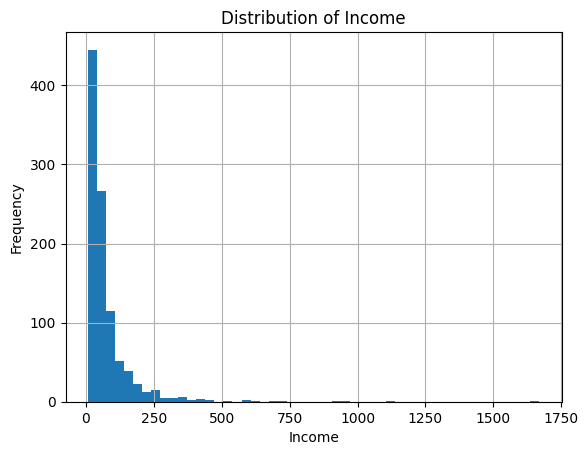

In [9]:
#load required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn
from sklearn import preprocessing
%matplotlib inline

#Load the required data
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/teleCust1000t.csv')
df.head()

#Data visualization and analyisis
df['custcat'].value_counts() # Corrected 'custcatt' to 'custcat'

# Generate the histogram for 'income' and set labels
ax_list = df.hist(column='income', bins=50)
ax = ax_list[0][0] # Access the AxesSubplot object
ax.set_xlabel('Income')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Income') # Add a title for clarity

df.columns # Corrected 'colums' to 'columns'
X = df[['region', 'tenure','age', 'marital', 'address', 'income', 'ed', 'employ','retire', 'gender', 'reside']] .values  #.astype(float)
X[0:5]
y=df['custcat'].values
y[0:5]

#Normalizing the data
X = preprocessing.StandardScaler().fit(X).transform(X.astype(float)) # Corrected 'standardscaler' to 'StandardScaler' and 'x' to 'X'

#Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=4) # Changed 'x' to 'X'
print('Train set:', x_train.shape, y_train.shape)
print('test set:',x_test.shape, y_train.shape)

#Classification
from sklearn.neighbors import KNeighborsClassifier
k=4
neigh=KNeighborsClassifier(n_neighbors=k).fit(x_train, y_train)
neigh
yhat=neigh.predict(x_test)
yhat[0:5]

#Accuracy evaluation
from sklearn import metrics
print("Train set Accuracy: ", metrics.accuracy_score(y_train, neigh.predict(x_train)))
print("Test set Accuracy: ", metrics.accuracy_score(y_test, yhat))

### Distribution of Customer Categories (`custcat`)

Let's visualize the distribution of our target variable, `custcat`. This will show us how many customers fall into each of the four categories.

/tmp/ipykernel_15219/3020027167.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='custcat', data=df, palette='viridis')


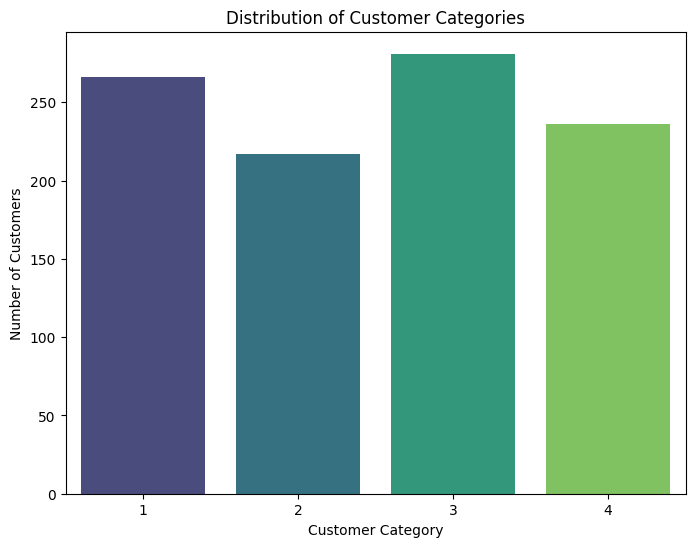

In [10]:
plt.figure(figsize=(8, 6))
sns.countplot(x='custcat', data=df, palette='viridis')
plt.title('Distribution of Customer Categories')
plt.xlabel('Customer Category')
plt.ylabel('Number of Customers')
plt.show()

### Distributions of Other Numerical Features

Next, let's look at the distributions of other numerical features like `tenure`, `age`, and `employ` using histograms.

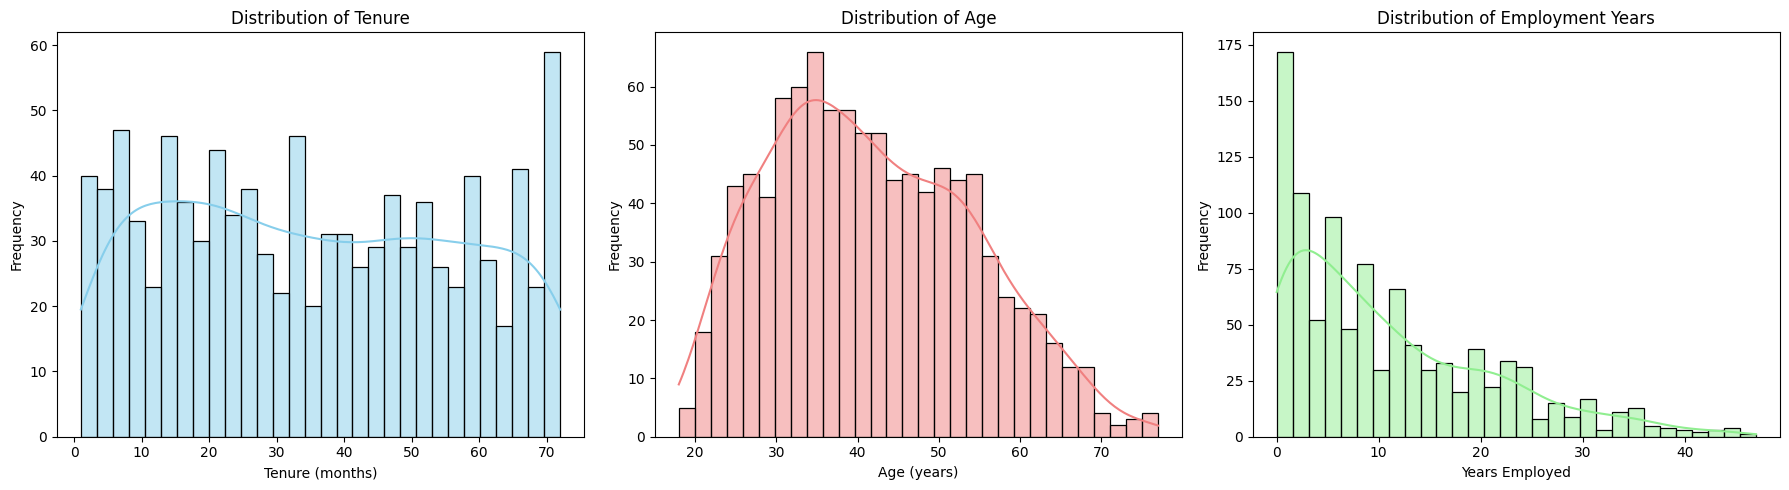

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['tenure'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Tenure')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Frequency')

sns.histplot(df['age'], bins=30, kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Age')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Frequency')

sns.histplot(df['employ'], bins=30, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Employment Years')
axes[2].set_xlabel('Years Employed')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Relationship Between Numerical Features and `custcat`

To see how numerical features vary across customer categories, let's use box plots for `income` and `tenure` against `custcat`.

/tmp/ipykernel_15219/366641358.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='custcat', y='income', data=df, palette='pastel', ax=axes[0])
/tmp/ipykernel_15219/366641358.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='custcat', y='tenure', data=df, palette='pastel', ax=axes[1])


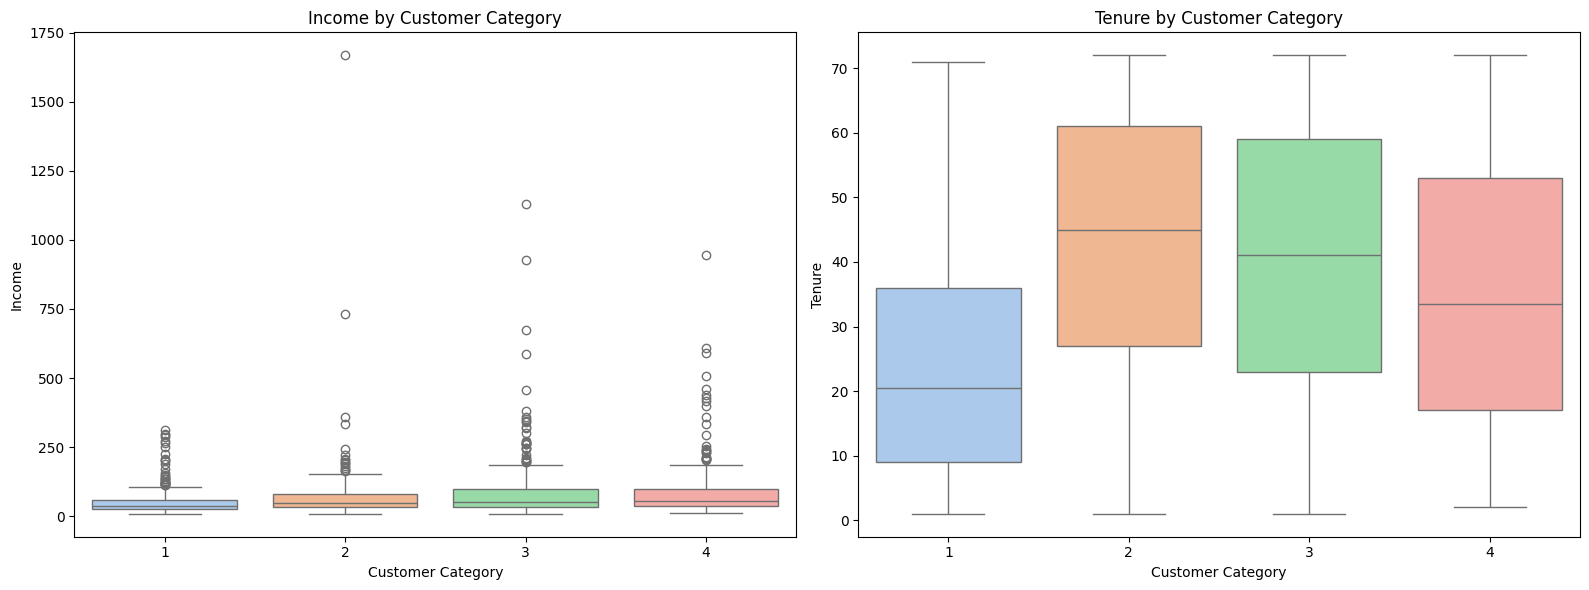

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='custcat', y='income', data=df, palette='pastel', ax=axes[0])
axes[0].set_title('Income by Customer Category')
axes[0].set_xlabel('Customer Category')
axes[0].set_ylabel('Income')

sns.boxplot(x='custcat', y='tenure', data=df, palette='pastel', ax=axes[1])
axes[1].set_title('Tenure by Customer Category')
axes[1].set_xlabel('Customer Category')
axes[1].set_ylabel('Tenure')

plt.tight_layout()
plt.show()

### Relationship Between Categorical Features and `custcat`

Finally, let's examine the relationship between a categorical feature like `gender` and `custcat` using a count plot, separated by gender.

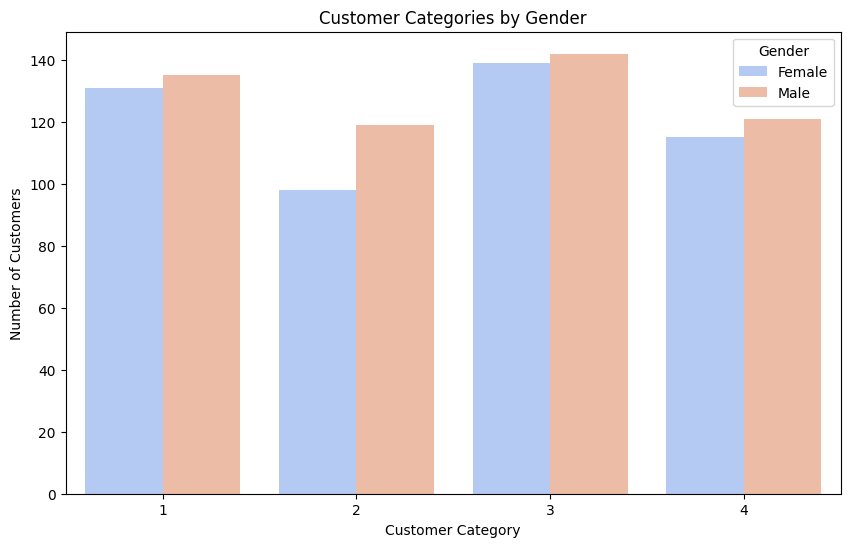

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(x='custcat', hue='gender', data=df, palette='coolwarm')
plt.title('Customer Categories by Gender')
plt.xlabel('Customer Category')
plt.ylabel('Number of Customers')
plt.legend(title='Gender', labels=['Female', 'Male']) # Assuming 0 for Female, 1 for Male or similar binary encoding
plt.show()

In [3]:
import pandas as pd
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/teleCust1000t.csv')
df.head(20)

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3
5,2,41,39,0,17,78.0,2,16,0.0,1,1,3
6,3,45,22,1,2,19.0,2,4,0.0,1,5,2
7,2,38,35,0,5,76.0,2,10,0.0,0,3,4
8,3,45,59,1,7,166.0,4,31,0.0,0,5,3
9,1,68,41,1,21,72.0,1,22,0.0,0,3,2
